# Post-hoc inference on Baseline checkpoints

Inference-only comparison on frozen checkpoints. **No model is retrained.**

Every inference rule is one cell of a **readout x transform** grid, and the same four cells are evaluated for every model:

|  | `node_score` | `subspace_norm` |
|---|---|---|
| **no transform** | rank each node by its own coordinate | rank it by the L2 norm over its ancestors+self+descendants subspace |
| **HCC projection** | `hcc_node_score` | `hcc_subspace_norm` |

Each checkpoint's own inference is one of these cells — `node_score` for H-CAST, HT-CapsNet and HRN, `subspace_norm` for Hier-COS, and the HCC-prefixed cell for a checkpoint trained with HCC — so the comparison asks one question of every model: **does aggregating over the taxonomy subspace, or projecting onto the hierarchy constraint, beat what the model already does?**

`subspace_norm` aggregates each model's **own per-level probabilities**, not raw logits, because an L2 norm is not invariant to a monotone map: `‖f(z)‖` is not a monotone function of `‖z‖`. Softmax for H-CAST and HT-CapsNet, sigmoid/sigmoid/softmax for HRN, identity for Hier-COS, whose training already drives non-target coordinate magnitudes to ~0. `node_score` is unaffected, since every one of those activations is monotone and cannot change a per-level argmax. Set `SUBSPACE_SCORE_SPACE = 'coordinate'` to reproduce raw-logit results.

**This notebook covers one training mechanism: baseline** — plain hierarchical training: no gradient-space projection and no output-space constraint. It is the reference every other mechanism is compared against, so the gains below are what a readout buys on top of ordinary training.

The key quantity here is the within-checkpoint **gain against that checkpoint's native cell**: the two rows come from one set of weights, so the only thing that differs is the inference rule. Positive always means the listed cell is better, including for the lower-is-better AHD and TICE. Every completed seed is evaluated separately; its YAML stays in that seed's run directory, and tables and plots report mean ± sample standard deviation with the seed count.

> To compare **mechanisms against each other** at any inference cell — HCC read with `hcc + subspace` against the baseline read with `subspace`, say — use [`all_mechanics.ipynb`](all_mechanics.ipynb). That comparison is not within-checkpoint and carries its own caveat, which is why it lives in its own notebook.

## Experimental cautions

1. H-CAST/HT-CapsNet/HRN coordinates were not trained as Hier-COS coordinates; identity-frame decoding is a post-hoc assumption.
2. The available best checkpoints were selected using each model's native validation inference. This can favor native inference.
3. Top-down and independent rows must use their corresponding best checkpoints. This notebook preserves that rule (`MATCHED_CHECKPOINT`).
4. Unequal seed coverage must be reported. A one-seed sign is suggestive, not robust evidence.
5. Treat this test-set analysis as a pre-specified ablation. Do not tune normalization or score variants repeatedly on test data.

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().resolve()
while not (REPO_ROOT / 'evaluation').is_dir() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
assert (REPO_ROOT / 'evaluation').is_dir(), 'Run this notebook from inside the repository.'
if str(REPO_ROOT / 'notebooks' / 'utils') not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / 'notebooks' / 'utils'))

import posthoc_inference_utils as posthoc

# ---- what to evaluate ----------------------------------------------------
EXPERIMENT_FAMILY = 'baseline'      # this notebook covers exactly one mechanism
DATASETS = posthoc.DATASETS         # ('cifar100', 'cub200', 'aircraft')
# Exact experiment roots to use. Values may be directory names underneath
# posthoc.OUTPUTS_ROOT or absolute Paths. Edit this mapping, then re-run below.
RUN_ROOTS = {
    'cifar100': {
        'hcast': 'hcast_cifar100',
        'htcapsnet': 'capsnet_cifar100',
        'hrn': 'hrn_cifar100_level_conditional',
        'hiercos': 'hiercos_cifar100_global_softmax_ce_reg_baseline_kl_leaf',
        'lhdnn': 'lhdnn_cifar100',
    },
    'cub200': {
        'hcast': 'hcast_cub200',
        'htcapsnet': 'capsnet_cub200',
        'hrn': 'hrn_cub200_level_conditional',
        'hiercos': 'hiercos_cub200_global_softmax_ce_reg_baseline_kl_leaf',
        'lhdnn': 'lhdnn_cub200',
    },
    'aircraft': {
        'hcast': 'hcast_aircraft',
        'htcapsnet': 'capsnet_aircraft',
        'hrn': 'hrn_aircraft_level_conditional',
        'hiercos': 'hiercos_aircraft_global_softmax_ce_reg_baseline_kl_leaf',
        'lhdnn': 'lhdnn_aircraft',
    },
}
RUN_EVALUATION = True               # the evaluation cell runs the checkpoint evaluator
OVERWRITE = False                   # True re-runs runs that already have a result file
DEVICE = None                       # None: cuda when available, else cpu
# 'all' evaluates the complete readout x transform grid; 'both' restricts it to
# node_score and subspace_norm. HCC-trained checkpoints need 'all' for their own
# native cell to be present.
INFERENCE_MODE = 'all'
# Space `subspace_norm` aggregates: 'probability' (default) or 'coordinate'.
SUBSPACE_SCORE_SPACE = 'probability'

# ---- figure settings -----------------------------------------------------
posthoc.THESIS_STYLE = True         # shared model-analysis paper style and text width
SAVE_PLOTS = True
PLOT_OUTPUT_DIR = (posthoc.OUTPUTS_ROOT / 'analysis' / 'inference_analysis'
                   / EXPERIMENT_FAMILY)

print(f'Mechanism: {EXPERIMENT_FAMILY} — '
      f'{posthoc.FAMILY_DESCRIPTIONS[EXPERIMENT_FAMILY]}')
print('Figures ->', PLOT_OUTPUT_DIR if SAVE_PLOTS else 'not saved')

Mechanism: baseline — plain hierarchical training, no gradient-space or output-space constraint
Figures -> /scratch/g.saggini1/outputs/analysis/inference_analysis/baseline


/home/g.saggini1/lexicographic_deep_learning_detailed_study/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Show every configured root, including selections that do not exist yet.
display(posthoc.run_roots_table(
    EXPERIMENT_FAMILY, datasets=DATASETS, roots=RUN_ROOTS))

# A run counts only if it has both validation-selected checkpoints, so a
# partial run never enters a mean.
run_table = posthoc.discover_runs(
    EXPERIMENT_FAMILY, datasets=DATASETS, roots=RUN_ROOTS)
display(posthoc.coverage_table(run_table))

,family,dataset_slug,model,run_root,root_exists
0,baseline,cifar100,hcast,/scratch/g.saggini1/outputs/hcast_cifar100,True
1,baseline,cifar100,htcapsnet,/scratch/g.saggini1/outputs/capsnet_cifar100,True
2,baseline,cifar100,hrn,/scratch/g.saggini1/outputs/hrn_cifar100_level...,True
3,baseline,cifar100,hiercos,/scratch/g.saggini1/outputs/hiercos_cifar100_g...,True
4,baseline,cifar100,lhdnn,/scratch/g.saggini1/outputs/lhdnn_cifar100,True
5,baseline,cub200,hcast,/scratch/g.saggini1/outputs/hcast_cub200,True
6,baseline,cub200,htcapsnet,/scratch/g.saggini1/outputs/capsnet_cub200,True
7,baseline,cub200,hrn,/scratch/g.saggini1/outputs/hrn_cub200_level_c...,True
8,baseline,cub200,hiercos,/scratch/g.saggini1/outputs/hiercos_cub200_glo...,True
9,baseline,cub200,lhdnn,/scratch/g.saggini1/outputs/lhdnn_cub200,True


,family,dataset_slug,model,runs,evaluated
0,baseline,aircraft,hcast,3,3
1,baseline,aircraft,hiercos,3,3
2,baseline,aircraft,hrn,3,3
3,baseline,aircraft,htcapsnet,3,3
4,baseline,aircraft,lhdnn,3,3
5,baseline,cifar100,hcast,3,3
6,baseline,cifar100,hiercos,3,3
7,baseline,cifar100,hrn,3,3
8,baseline,cifar100,htcapsnet,3,3
9,baseline,cifar100,lhdnn,3,3


In [3]:
# Run this cell from one kernel at a time: the evaluator checks for an existing
# output before it starts and again when it saves, so a second concurrent copy of
# the sweep makes whichever process is slower fail at save time.
result_files = posthoc.evaluate_runs(
    run_table,
    run_evaluation=RUN_EVALUATION,
    overwrite=OVERWRITE,
    device=DEVICE,
    inference_mode=INFERENCE_MODE,
    subspace_score_space=SUBSPACE_SCORE_SPACE,
)

[reuse] /scratch/g.saggini1/outputs/hcast_cifar100/seed_0/posthoc_inference_test_metrics.yaml
[reuse] /scratch/g.saggini1/outputs/hcast_cifar100/seed_1/posthoc_inference_test_metrics.yaml
[reuse] /scratch/g.saggini1/outputs/hcast_cifar100/seed_2/posthoc_inference_test_metrics.yaml
[reuse] /scratch/g.saggini1/outputs/capsnet_cifar100/seed_0/posthoc_inference_test_metrics.yaml
[reuse] /scratch/g.saggini1/outputs/capsnet_cifar100/seed_1/posthoc_inference_test_metrics.yaml
[reuse] /scratch/g.saggini1/outputs/capsnet_cifar100/seed_2/posthoc_inference_test_metrics.yaml
[reuse] /scratch/g.saggini1/outputs/hrn_cifar100_level_conditional/seed_0/posthoc_inference_test_metrics.yaml
[reuse] /scratch/g.saggini1/outputs/hrn_cifar100_level_conditional/seed_1/posthoc_inference_test_metrics.yaml
[reuse] /scratch/g.saggini1/outputs/hrn_cifar100_level_conditional/seed_2/posthoc_inference_test_metrics.yaml
[reuse] /scratch/g.saggini1/outputs/hiercos_cifar100_global_softmax_ce_reg_baseline_kl_leaf/seed_0/p

In [4]:
# Every decoder and every cell is loaded; selection happens in the next cell, so
# switching between independent, top-down or both never needs a reload.
results_long = posthoc.add_series(posthoc.load_results(run_table), by='model')
if not results_long.empty:
    display(results_long.groupby(['dataset', 'model'])['inference']
            .agg(lambda values: ', '.join(sorted(set(values))))
            .reset_index().rename(columns={'inference': 'available inference cells'}))

Loaded rows: 5040


,dataset,model,available inference cells
0,cifar-100,hcast,"hcc_node_score, hcc_subspace_norm, node_score,..."
1,cifar-100,hiercos,"hcc_node_score, hcc_subspace_norm, node_score,..."
2,cifar-100,hrn,"hcc_node_score, hcc_subspace_norm, node_score,..."
3,cifar-100,ht_capsnet,"hcc_node_score, hcc_subspace_norm, node_score,..."
4,cifar-100,lhdnn,"hcc_node_score, hcc_subspace_norm, node_score,..."
5,cub-200-2011,hcast,"hcc_node_score, hcc_subspace_norm, node_score,..."
6,cub-200-2011,hiercos,"hcc_node_score, hcc_subspace_norm, node_score,..."
7,cub-200-2011,hrn,"hcc_node_score, hcc_subspace_norm, node_score,..."
8,cub-200-2011,ht_capsnet,"hcc_node_score, hcc_subspace_norm, node_score,..."
9,cub-200-2011,lhdnn,"hcc_node_score, hcc_subspace_norm, node_score,..."


In [5]:
# =====================  WHAT TO SHOW  =====================================
# Edit these, then re-run this cell and the ones below.
SHOW_INFERENCES = 'all'      # 'all' | 'native' | e.g. ['node_score', 'hcc_node_score']
SHOW_DECODERS = 'both'       # 'both' | 'independent' | 'topdown'
SHOW_DATASETS = 'all'        # 'all' | e.g. ['cifar-100', 'fgvc-aircraft']
SHOW_MODELS = 'all'          # 'all' | e.g. ['hcast', 'hiercos']
SHOW_METRICS = ('fpa', 'weighted_ap', 'tice', 'ahd')   # add 'acc_level_0', ...
MATCHED_CHECKPOINT = True    # repo rule: read each decoder from its own checkpoint
# The best-cell table below takes one decoder rather than a set. It follows
# SHOW_DECODERS when it names one, and reads independent decoding when it is
# 'both'.
BEST_CHART_DECODER = 'topdown' if SHOW_DECODERS == 'topdown' else 'independent'
# ==========================================================================

view = posthoc.select(results_long, inferences=SHOW_INFERENCES, decoders=SHOW_DECODERS,
                      datasets=SHOW_DATASETS, models=SHOW_MODELS, metrics=SHOW_METRICS,
                      matched_checkpoint=MATCHED_CHECKPOINT)
posthoc.describe_selection(view, MATCHED_CHECKPOINT)

Selected 1440 rows
  inference cells : node_score, subspace_norm, hcc_node_score, hcc_subspace_norm
  decoders        : independent, topdown
  datasets        : cifar-100, cub-200-2011, fgvc-aircraft
  models          : hcast, hiercos, hrn, ht_capsnet, lhdnn
  mechanisms      : baseline
  metrics         : ahd, fpa, tice, weighted_ap
  checkpoint rule : matched to decoder


In [6]:
absolute_summary = posthoc.absolute_summary(view)
# The reference is the full loaded table, so deselecting the native cell above
# does not remove the row the gains are measured against.
paired = posthoc.paired_gains(view, reference=results_long)
gain_summary = posthoc.gain_summary(paired)

# Both frames carry every (dataset, model, decoder, cell, metric) combination,
# which is a few hundred printed lines and unreadable as a table. They are the
# input of the two grids in sections 1 and 2, which lay the same numbers out so
# they can be compared; display one here only to look a single value up.
print(f'absolute values : {len(absolute_summary)} rows (mean, sample SD, seeds)')
if paired.empty:
    print('paired gains    : none — only the native cell is selected, '
          'or its row is missing')
else:
    print(f'paired gains    : {len(paired)} per-seed rows → '
          f'{len(gain_summary)} aggregated, against the native cell '
          f"({', '.join(sorted(set(paired['native_cell'])))}); "
          'positive favours the listed cell, for every metric')

absolute values : 480 rows (mean, sample SD, seeds)
paired gains    : 1080 per-seed rows → 360 aggregated, against the native cell (node_score, subspace_norm); positive favours the listed cell, for every metric


## How to read the figures

All figures are drawn at their printed size (`posthoc.TEXT_WIDTH_IN`, default 6.3 in) and saved as
PDF for LaTeX plus PNG for previews. The notebook prints the saved paths but no LaTeX figure
environment. With `posthoc.THESIS_STYLE = True`, the title and methodological explanation belong to the
LaTeX caption rather than the image.

Sections 1 and 2 map the whole grid; sections 3 to 6 then take **one factor at a time**, in the
order the factors are defined — readout, then decoder, then transform — with each section answering
a question the previous one raises:

1. **Relative effect grid.** Each tile is the gain against that checkpoint's own native readout,
   sign-adjusted so positive is always better, including for lower-is-better TICE and AHD. `native`
   marks the zero-reference cell and `†` marks an effect whose sign varies across seeds.
2. **Absolute level grid.** The same geometry in raw test units. Read it directly beside the
   relative grid: a gain is interpretable only after checking the level on which it sits. Shading
   is normalised inside each dataset block and darker is always better.
3. **Where the readout acts.** The grid says how much `subspace_norm` buys, not where. Each bar is
   the paired per-level accuracy change `Acc(subspace_norm) - Acc(node_score)` in percentage
   points, which separates better leaf recognition from cross-level reconciliation.
4. **Top-down versus independent decoding.** With the readout now understood, what the hard decoder
   still adds. Each bar is the per-seed relative FPA change `100 (td - ind) / ind`, averaged only
   after pairing, with one bar per readout so the conditioning is visible in one place. A `+5%` bar
   means 5% more complete paths, not a 5 percentage-point change.
5. **Soft readout against top-down decoding.** Whether the subspace readout under independent
   decoding already does what the hard top-down decoder does, in percentage points of FPA,
   paired per seed. It shares the geometry of figure 4, so the two read as a pair.
6. **Post-hoc HCC.** The last factor of the grid: what the constraint does at inference alone, on
   checkpoints never trained under it. A table, not a figure, because the interesting structure is
   the interaction with the readout and an algebraic invariance check.

## 1. Relative effects against native inference

This grid isolates the inference rule within each checkpoint. Every tile is measured against that
same checkpoint's native cell, so positive values indicate an improvement and negative values a
deterioration.

[note] 12 columns need 6.40 in; at width=\textwidth LaTeX scales it to 92% (tile labels land at 6.3 pt). Show fewer metrics, or place it on a landscape page.


**Gain of every inference cell against the checkpoint’s own readout**  
datasets: CIFAR-100, CUB-200, Aircraft · rows: H-CAST, HT-CapsNet, HRN, Hier-COS, LH-DNN · independent and top-down decoding · metrics: FPA, TICE

[saved] /scratch/g.saggini1/outputs/analysis/inference_analysis/baseline/effect_grid.pdf


[saved] /scratch/g.saggini1/outputs/analysis/inference_analysis/baseline/effect_grid.png


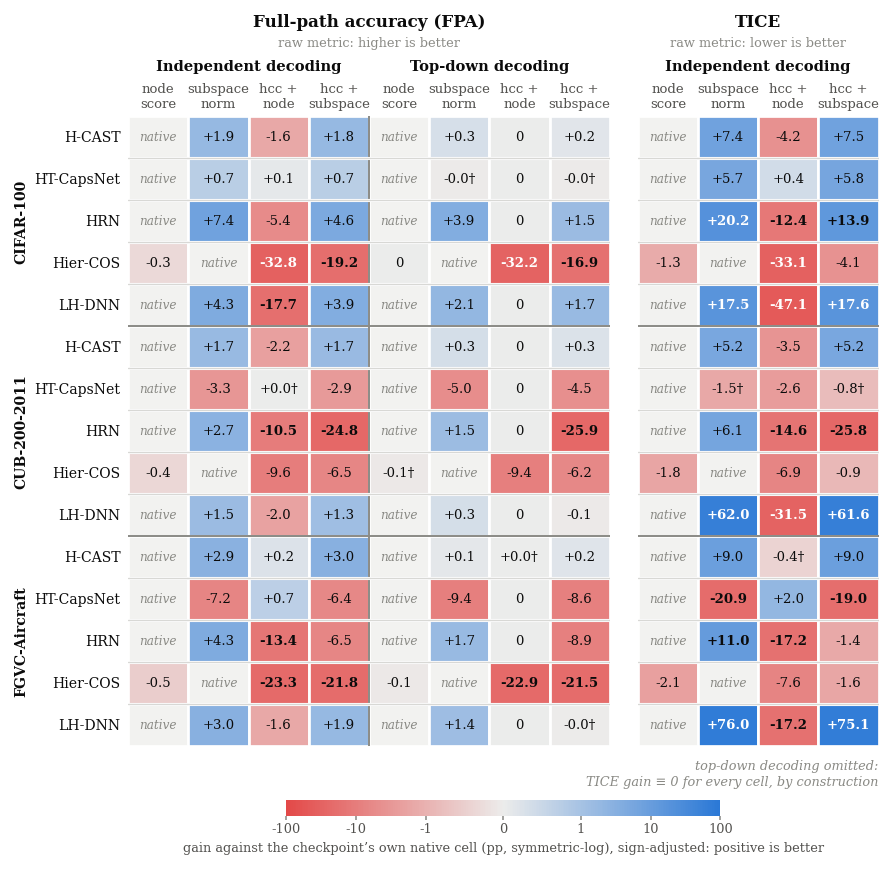

In [7]:
GRID_METRICS = ('fpa', 'tice')          # any subset of posthoc.METRIC_SPECS

if absolute_summary.empty:
    print('Nothing to plot for the current selection.')
else:
    if SAVE_PLOTS:
        PLOT_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

    def path(name):
        return (PLOT_OUTPUT_DIR / f'{name}.pdf') if SAVE_PLOTS else None

    posthoc.effect_grid(gain_summary, paired, absolute_summary,
                        metrics=GRID_METRICS, save_path=path('effect_grid'))

## 2. Absolute values corresponding to the relative effects

The grid below has the same rows and inference cells as the relative grid immediately above, but
reports raw test values. Use the pair together: the first shows what changed relative to native
inference, while this one shows the absolute level and the comparison with other models on the same
dataset.

[note] 12 columns need 6.48 in; at width=\textwidth LaTeX scales it to 91%.


**Raw test values of every inference cell**  
datasets: CIFAR-100, CUB-200, Aircraft · rows: H-CAST, HT-CapsNet, HRN, Hier-COS, LH-DNN · independent and top-down decoding · metrics: FPA, TICE

[saved] /scratch/g.saggini1/outputs/analysis/inference_analysis/baseline/absolute_grid.pdf


[saved] /scratch/g.saggini1/outputs/analysis/inference_analysis/baseline/absolute_grid.png


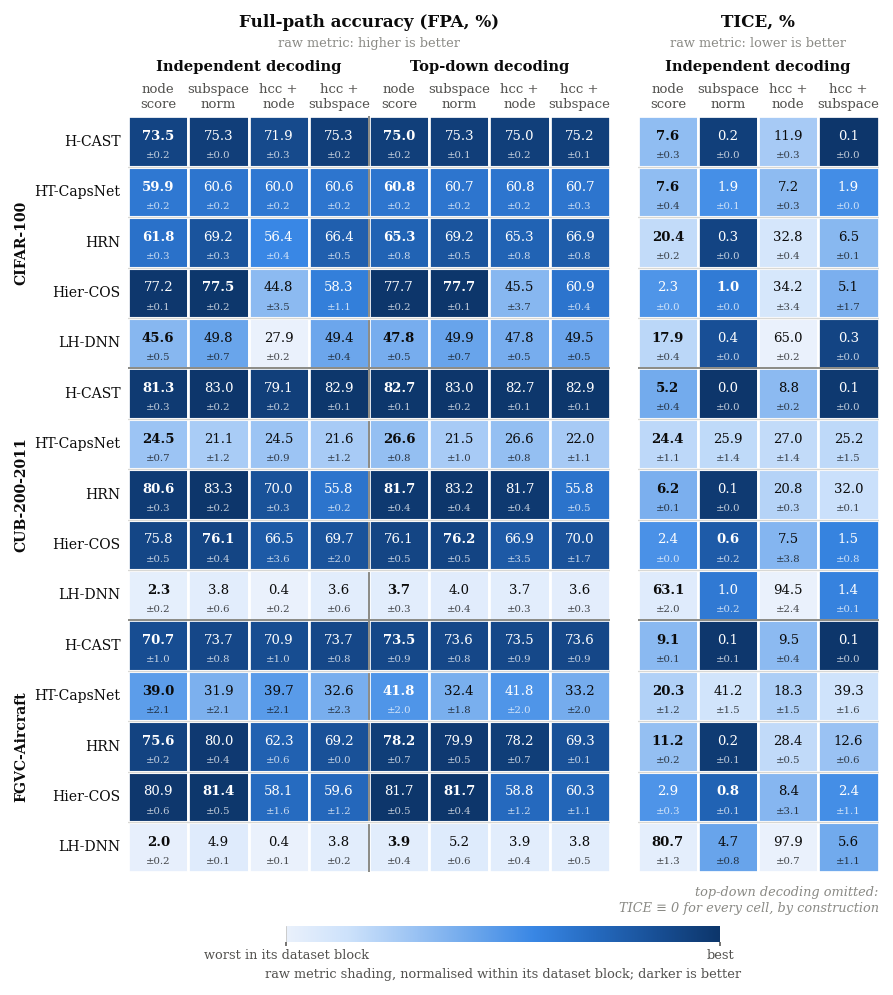

In [8]:
ABS_GRID_METRICS = GRID_METRICS      # any subset of posthoc.METRIC_SPECS
ABS_SHOW_SPREAD = True               # print the sample SD under each mean
# 'dataset' compares every model on the same dataset; 'row' rescales inside each
# model; 'panel' uses one ramp for the entire metric panel.
ABS_SHADE_SCOPE = 'dataset'

if absolute_summary.empty:
    print('Nothing to plot for the current selection.')
else:
    posthoc.absolute_grid(absolute_summary, metrics=ABS_GRID_METRICS,
                          show_spread=ABS_SHOW_SPREAD, shade_scope=ABS_SHADE_SCOPE,
                          show_footer=False,
                          save_path=path('absolute_grid'))

## 3. Where along the path does the subspace readout act?

The grids say *how much* the subspace norm buys in FPA and what it leaves in TICE, but not *where*
along the path it acts, and FPA alone cannot separate the two mechanisms that would produce the
same gain. Better leaf recognition would raise the fine accuracy. Cross-level reconciliation would
instead raise the coarse and middle accuracies — a subspace score folds a node's ancestors and
descendants into it — and may spend a little of the leaf to do it.

Splitting the change per level separates them. Each bar is
`Acc(subspace_norm) - Acc(node_score)` at one level, in percentage points, paired per seed on the
same checkpoint: both cells come from one forward pass, so a bar is an inference effect and never a
training difference. Percentage points rather than the relative change of section 4, because a level
accuracy that has collapsed to a few percent makes a ratio describe the collapse instead of the
readout.

Colour encodes the level and the side of the zero line encodes the sign, so the reconciliation
signature is a row whose coarse and middle bars point right while its fine bar points left. This is
also the view that says which level a failure *starts* at when the readout hurts a family.

**Where along the path the subspace readout acts**  
datasets: CIFAR-100, CUB-200, Aircraft · rows: H-CAST, HT-CapsNet, HRN, Hier-COS, LH-DNN · independent decoding · per-level accuracy change, paired per seed

[saved] /scratch/g.saggini1/outputs/analysis/inference_analysis/baseline/readout_level_gain.pdf
[saved] /scratch/g.saggini1/outputs/analysis/inference_analysis/baseline/readout_level_gain.png


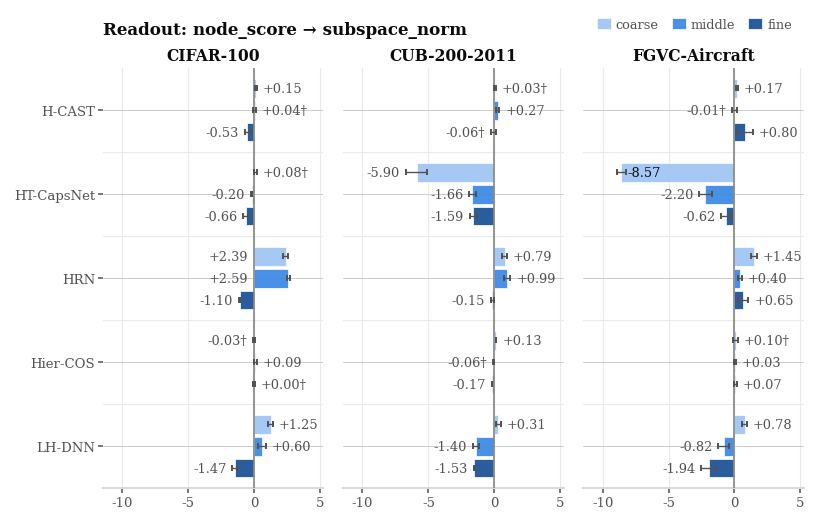

Per-level accuracy under each readout and the paired change (independent decoding, mean over seeds):


,dataset,model,level,node_score %,subspace_norm %,subspace - node (pp),delta SD,seeds,same sign in every seed
0,cifar-100,hcast,coarse,90.820,90.970,0.150,0.050,3,True
1,cifar-100,hcast,middle,85.203,85.243,0.040,0.104,3,False
2,cifar-100,hcast,fine,75.937,75.403,-0.533,0.191,3,True
3,cifar-100,ht_capsnet,coarse,84.523,84.607,0.083,0.106,3,False
4,cifar-100,ht_capsnet,middle,75.613,75.417,-0.197,0.040,3,True
5,cifar-100,ht_capsnet,fine,61.617,60.960,-0.657,0.170,3,True
6,cifar-100,hrn,coarse,84.647,87.037,2.390,0.200,3,True
7,cifar-100,hrn,middle,77.165,79.755,2.590,0.110,3,True
8,cifar-100,hrn,fine,70.380,69.275,-1.105,0.045,3,True
9,cifar-100,hiercos,coarse,91.380,91.350,-0.030,0.056,3,False


In [9]:
LEVEL_DECODER = 'independent'   # 'independent' | 'topdown'

if absolute_summary.empty:
    print('Nothing to compare for the current selection.')
else:
    datasets = [d for d in posthoc.DATASET_ORDER if d in set(view['dataset'])]
    series = posthoc.order_series(set(view['series']))
    # results_long, not view: the per-level metrics are needed whatever
    # SHOW_METRICS happens to select above.
    level_summary = posthoc.readout_level_gains(results_long, datasets=datasets,
                                                series=series, decoder=LEVEL_DECODER)
    if level_summary.empty:
        print('No matched node_score/subspace_norm level accuracies for this selection.')
    else:
        posthoc.readout_level_figure(level_summary, datasets=datasets, series=series,
                                     decoder=LEVEL_DECODER, show_footer=False,
                                     save_path=path('readout_level_gain'))
        print('Per-level accuracy under each readout and the paired change '
              f'({posthoc.DECODER_SHORT[LEVEL_DECODER]} decoding, mean over seeds):')
        display(level_summary.assign(
            level=level_summary['metric_family'].map(posthoc.LEVEL_LABELS)).rename(columns={
                'series': 'model', 'node_score': 'node_score %',
                'subspace_norm': 'subspace_norm %', 'delta_pp': 'subspace - node (pp)',
                'delta_std': 'delta SD', 'sign_agrees': 'same sign in every seed'})
            .drop(columns='metric_family')
            [['dataset', 'model', 'level', 'node_score %', 'subspace_norm %',
              'subspace - node (pp)', 'delta SD', 'seeds',
              'same sign in every seed']].round(3))


## 4. Top-down versus independent decoding

With the readout fixed, this section measures what top-down decoding contributes relative to
independent decoding. The quantity is a relative FPA change, formed per seed before aggregation.
Top-down and independent values are read from their corresponding validation-selected checkpoints.

Each readout gets its own plot, stacked on one shared horizontal scale, because the answer is not a
single number but a conditioning: the hard decoder is worth having under `node_score`, and section 3
has just shown why it should have little left to do once `subspace_norm` has already folded ancestor
evidence into every score.

**What top-down decoding buys, under each readout**  
datasets: CIFAR-100, CUB-200, Aircraft · rows: H-CAST, HT-CapsNet, HRN, Hier-COS, LH-DNN · relative FPA change, paired per seed

[saved] /scratch/g.saggini1/outputs/analysis/inference_analysis/baseline/decoder_gain.pdf
[saved] /scratch/g.saggini1/outputs/analysis/inference_analysis/baseline/decoder_gain.png


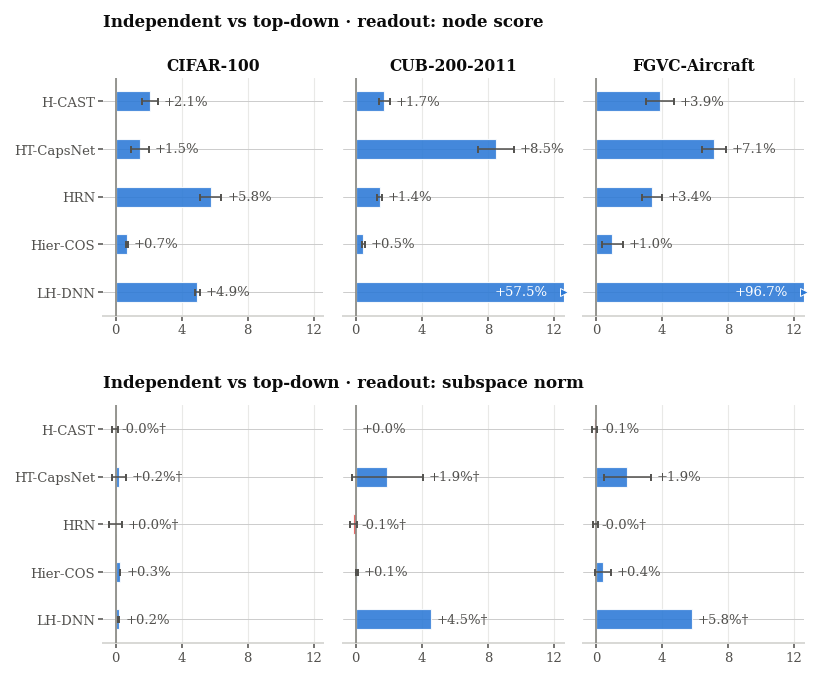

Relative gain of top-down over independent decoding (test FPA; per-seed 100*(td-ind)/ind, mean ± sample SD):


,dataset,model,readout,independent FPA %,independent SD,top-down FPA %,top-down − independent (pp),relative gain %,relative SD,seeds,same sign in every seed,weak_baseline
0,cifar-100,hcast,node_score,73.477,0.187,75.010,1.533,2.088,0.496,3,True,False
1,cifar-100,ht_capsnet,node_score,59.870,0.207,60.757,0.887,1.482,0.548,3,True,False
2,cifar-100,hrn,node_score,61.758,0.340,65.321,3.562,5.766,0.641,3,True,False
3,cifar-100,hiercos,node_score,77.213,0.132,77.737,0.523,0.678,0.073,3,True,False
4,cifar-100,lhdnn,node_score,45.570,0.480,47.823,2.253,4.945,0.144,3,True,False
5,cub-200-2011,hcast,node_score,81.268,0.329,82.683,1.415,1.742,0.327,3,True,False
6,cub-200-2011,ht_capsnet,node_score,24.479,0.744,26.556,2.077,8.490,1.104,3,True,False
7,cub-200-2011,hrn,node_score,80.560,0.286,81.728,1.168,1.449,0.143,3,True,False
8,cub-200-2011,hiercos,node_score,75.785,0.458,76.130,0.345,0.455,0.080,3,True,False
9,cub-200-2011,lhdnn,node_score,2.330,0.233,3.665,1.335,57.451,2.566,3,True,True


In [10]:
if absolute_summary.empty:
    print('Nothing to compare for the current selection.')
else:
    datasets = [d for d in posthoc.DATASET_ORDER if d in set(view['dataset'])]
    series = posthoc.order_series(set(view['series']))
    decoder_summary = posthoc.relative_decoder_gains(results_long, datasets=datasets,
                                                     series=series)
    if decoder_summary.empty:
        print('No matched independent/top-down rows for the current selection.')
    else:
        # One figure, one plot per readout on a shared scale: each readout stays
        # readable on its own, and the contrast between them needs no page flip.
        posthoc.decoder_gain_readout_figure(decoder_summary, datasets=datasets,
                                            series=series, show_footer=False,
                                            save_path=path('decoder_gain'))
        print('Relative gain of top-down over independent decoding '
              '(test FPA; per-seed 100*(td-ind)/ind, mean ± sample SD):')
        display(decoder_summary.rename(columns={
            'inference': 'readout', 'series': 'model',
            'independent_fpa': 'independent FPA %', 'independent_std': 'independent SD',
            'topdown_fpa': 'top-down FPA %', 'delta_pp': 'top-down − independent (pp)',
            'relative_gain': 'relative gain %', 'relative_std': 'relative SD',
            'sign_agrees': 'same sign in every seed'}).round(3))

## 5. Does the soft readout make top-down decoding unnecessary?

The two rules impose the hierarchy in different ways. Top-down decoding is the **hard** one: it makes
an inconsistent path unreachable, by restricting each level's argmax to the children of the level
above. `subspace_norm` is the **soft** one: it forbids nothing, and instead folds a node's ancestors
into its own score, so a path whose levels disagree is outranked rather than excluded. Section 4
therefore leaves an obvious question: are the two doing the same work twice? This section asks it
head-to-head — the soft cell under **independent** decoding against the
**top-down** decoder on that checkpoint's own native cell, paired per seed and reported in
percentage points. A bar right of zero means the readout alone matches or beats the hard decoder:
the constraint bought no accuracy the score did not already carry.

Accuracy is only half of the claim, because top-down decoding has TICE identically zero by
construction. The table therefore also carries the residual TICE the soft readout leaves, next to
the native readout's own TICE, so a bar right of zero can be checked against what it costs in
consistency before it is read as a win.

Where a checkpoint's native cell *is* the subspace norm — Hier-COS, and any HCC-trained run read at
`hcc_subspace_norm` — the readout is held fixed and the bar reduces to the decoder effect of
section 4, on the opposite sign convention. That row says what dropping top-down costs, not what
the readout buys.

**How much of top-down decoding the soft readout recovers**  
datasets: CIFAR-100, CUB-200, Aircraft · rows: H-CAST, HT-CapsNet, HRN, Hier-COS, LH-DNN · FPA difference in pp, paired per seed

[saved] /scratch/g.saggini1/outputs/analysis/inference_analysis/baseline/topdown_recovery.pdf
[saved] /scratch/g.saggini1/outputs/analysis/inference_analysis/baseline/topdown_recovery.png


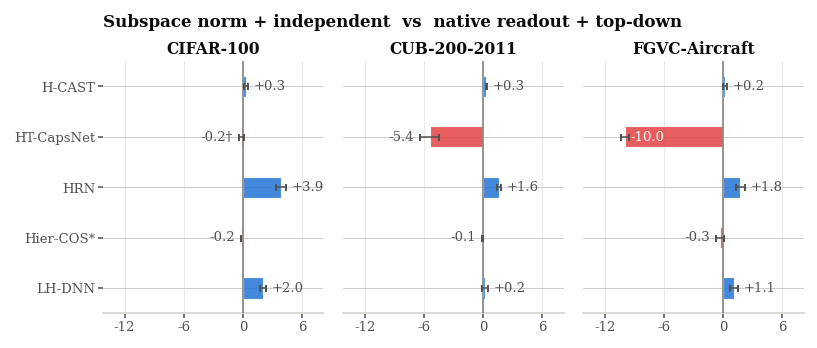

Soft readout under independent decoding against top-down decoding (test FPA %, mean over seeds; TICE under independent decoding):


,dataset,model,soft cell,native cell,soft FPA %,soft SD,top-down FPA %,top-down SD,soft − top-down (pp),delta SD,seeds,same sign in every seed,soft TICE %,native TICE %
0,cifar-100,hcast,subspace_norm,node_score,75.343,0.046,75.010,0.180,0.333,0.186,3,True,0.210,7.613
1,cifar-100,ht_capsnet,subspace_norm,node_score,60.600,0.173,60.757,0.227,-0.157,0.274,3,False,1.950,7.627
2,cifar-100,hrn,subspace_norm,node_score,69.193,0.285,65.321,0.755,3.873,0.470,3,True,0.284,20.449
3,cifar-100,hiercos,subspace_norm,subspace_norm,77.520,0.156,77.737,0.144,-0.217,0.015,3,True,1.043,1.043
4,cifar-100,lhdnn,subspace_norm,node_score,49.830,0.687,47.823,0.512,2.007,0.315,3,True,0.443,17.897
5,cub-200-2011,hcast,subspace_norm,node_score,83.017,0.150,82.683,0.149,0.334,0.036,3,True,0.029,5.235
6,cub-200-2011,ht_capsnet,subspace_norm,node_score,21.137,1.176,26.556,0.788,-5.419,0.955,3,True,25.946,24.433
7,cub-200-2011,hrn,subspace_norm,node_score,83.310,0.240,81.728,0.375,1.582,0.190,3,True,0.098,6.208
8,cub-200-2011,hiercos,subspace_norm,subspace_norm,76.148,0.424,76.211,0.465,-0.063,0.043,3,True,0.598,0.598
9,cub-200-2011,lhdnn,subspace_norm,node_score,3.849,0.571,3.665,0.311,0.184,0.275,3,True,1.047,63.054


In [11]:
# The soft cell defaults to the subspace-norm cell that matches each checkpoint's
# own transform ('hcc_subspace_norm' for an HCC-trained run, 'subspace_norm'
# otherwise); name a cell here to force one instead.
SOFT_CELL = None

if absolute_summary.empty:
    print('Nothing to compare for the current selection.')
else:
    datasets = [d for d in posthoc.DATASET_ORDER if d in set(view['dataset'])]
    series = posthoc.order_series(set(view['series']))
    recovery = posthoc.topdown_recovery_gains(results_long, soft_cell=SOFT_CELL,
                                              datasets=datasets, series=series)
    if recovery.empty:
        print('No matched independent/top-down rows for the current selection.')
    else:
        posthoc.topdown_recovery_figure(recovery, datasets=datasets, series=series,
                                        show_footer=False,
                                        save_path=path('topdown_recovery'))
        print('Soft readout under independent decoding against top-down decoding '
              '(test FPA %, mean over seeds; TICE under independent decoding):')
        display(recovery.rename(columns={
            'series': 'model', 'soft_cell': 'soft cell', 'native_cell': 'native cell',
            'soft_fpa': 'soft FPA %', 'soft_std': 'soft SD',
            'topdown_fpa': 'top-down FPA %', 'topdown_std': 'top-down SD',
            'delta_pp': 'soft − top-down (pp)', 'delta_std': 'delta SD',
            'sign_agrees': 'same sign in every seed',
            'soft_tice': 'soft TICE %', 'native_tice': 'native TICE %'}).round(3))

## 6. Post-hoc HCC, and which cell wins overall

The transform is the one factor of the grid left. HCC can be applied to a checkpoint that was never
trained under it, at no training cost, so it separates a pure inference-time correction from the
extra effect of training under the constraint: a trained-HCC arm has to beat this control before
anything can be attributed to learning.

The claim to test is a **joint** one — the transform is sold as a consistency repair, so it has to
lower TICE without paying too much FPA — which is why the figure plots the pair rather than either
alone. Each point is one (model, dataset) cell, at the FPA change it makes horizontally and the TICE
change vertically. Deltas are raw and **not** sign-adjusted, so right is better on FPA, down is
better on TICE, and the two shaded corners are the quadrants where the two metrics agree. The axes
are symmetric-log because the effects span two orders of magnitude, from Hier-COS losing 32 pp of
FPA to H-CAST moving by 0.06 pp.

What the transform can do at all depends on the readout. For a signed value readout the projection
shifts every sibling group by one constant, which cannot reorder a sibling set and therefore cannot
move any top-down metric — that is the last column of the table, an algebraic check rather than a
result, and it is expected to be non-zero only for Hier-COS, which ranks coordinate magnitudes
rather than signed values. Both subspace-norm rows are outside the invariance for the same reason: a
norm mixes coordinates from more than one level.

The table carries the exact values, their spread and that check; the last table then closes the grid
by naming, for each model, the cell with the largest FPA and by how much it beats that checkpoint's
native cell.

**What the HCC transform does on its own, on both metrics at once**  
datasets: CIFAR-100, CUB-200, Aircraft · rows: H-CAST, HT-CapsNet, HRN, Hier-COS, LH-DNN · independent decoding · HCC minus no transform, paired per seed

[saved] /scratch/g.saggini1/outputs/analysis/inference_analysis/baseline/posthoc_hcc_effect.pdf


[saved] /scratch/g.saggini1/outputs/analysis/inference_analysis/baseline/posthoc_hcc_effect.png


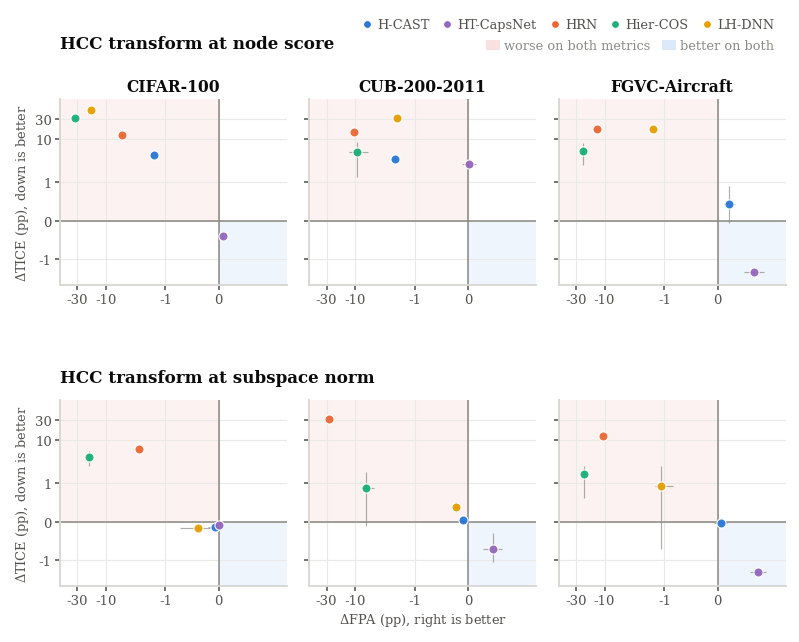

Post-hoc HCC on each frozen checkpoint, under independent decoding (Δ = HCC minus no transform on the same checkpoint and readout, pp; positive ΔTICE is unfavourable):


,model,dataset,node ΔFPA,node ΔTICE,subspace ΔFPA,subspace ΔTICE,top-down node ΔFPA
0,H-CAST,cifar-100,-1.57,4.24,-0.06,-0.14,0.00
1,H-CAST,cub-200-2011,-2.19,3.53,-0.09,0.05,0.00
2,H-CAST,fgvc-aircraft,0.22,0.43,0.06,-0.03,0.01
3,HT-CapsNet,cifar-100,0.09,-0.39,0.01,-0.09,0.00
4,HT-CapsNet,cub-200-2011,0.02,2.61,0.46,-0.70,0.00
5,HT-CapsNet,fgvc-aircraft,0.69,-2.03,0.76,-1.88,0.00
6,HRN,cifar-100,-5.37,12.36,-2.81,6.24,0.00
7,HRN,cub-200-2011,-10.53,14.57,-27.56,31.88,0.00
8,HRN,fgvc-aircraft,-13.35,17.23,-10.79,12.45,0.00
9,Hier-COS,cifar-100,-32.45,31.85,-19.23,4.10,-32.24



Best cell per (dataset, model), by FPA under independent decoding:


,dataset,model,best_family,best_inference,best_value,best_std,native_inference,native_value,margin,runner_up,runner_up_family,seeds
0,cifar-100,hcast,baseline,subspace_norm,75.343333,0.046188,node_score,73.476667,0.063333,hcc_subspace_norm,baseline,3
1,cifar-100,hiercos,baseline,subspace_norm,77.520000,0.156205,subspace_norm,77.520000,0.306667,node_score,baseline,3
2,cifar-100,hrn,baseline,subspace_norm,69.193269,0.285360,node_score,61.758269,2.810000,hcc_subspace_norm,baseline,3
3,cifar-100,ht_capsnet,baseline,hcc_subspace_norm,60.613333,0.159478,node_score,59.870000,0.013333,subspace_norm,baseline,3
4,cifar-100,lhdnn,baseline,subspace_norm,49.830000,0.686950,node_score,45.570000,0.390000,hcc_subspace_norm,baseline,3
5,cub-200-2011,hcast,baseline,subspace_norm,83.016914,0.150462,node_score,81.267978,0.092049,hcc_subspace_norm,baseline,3
6,cub-200-2011,hiercos,baseline,subspace_norm,76.147739,0.423819,subspace_norm,76.147739,0.362444,node_score,baseline,3
7,cub-200-2011,hrn,baseline,subspace_norm,83.310321,0.239773,node_score,80.560350,2.749971,node_score,baseline,3
8,cub-200-2011,ht_capsnet,baseline,hcc_node_score,24.496606,0.873995,node_score,24.479346,0.017259,node_score,baseline,3
9,cub-200-2011,lhdnn,baseline,subspace_norm,3.848809,0.570600,node_score,2.329997,0.230123,hcc_subspace_norm,baseline,3


In [12]:
if absolute_summary.empty:
    print('Nothing to compare for the current selection.')
else:
    datasets = [d for d in posthoc.DATASET_ORDER if d in set(view['dataset'])]
    series = posthoc.order_series(set(view['series']))
    # the figure carries the joint FPA/TICE claim, the table the exact values
    # and the top-down invariance check, which is not plottable: it is
    # identically zero for every family that ranks signed coordinates
    hcc_effects = posthoc.transform_effects(results_long, datasets=datasets,
                                            series=series)
    posthoc.transform_effect_figure(hcc_effects, datasets=datasets, series=series,
                                    show_footer=False,
                                    save_path=path('posthoc_hcc_effect'))
    print('Post-hoc HCC on each frozen checkpoint, under independent decoding '
          '(Δ = HCC minus no transform on the same checkpoint and readout, pp; '
          'positive ΔTICE is unfavourable):')
    display(posthoc.transform_effect_table(results_long, datasets=datasets,
                                           series=series))

    print(f'\nBest cell per (dataset, model), by FPA under '
          f'{posthoc.DECODER_SHORT[BEST_CHART_DECODER]} decoding:')
    display(posthoc.best_cells(absolute_summary, metric='fpa',
                               decoder=BEST_CHART_DECODER))

## Reading the results

Two properties of `subspace_norm` are facts about the rule, not results, and both have to be held
onto before any tile is interpreted. It squares its inputs, so it discards the sign of whatever it
aggregates. In the default `probability` space that is harmless — the aggregated values are already
non-negative evidence, and a confidently rejected class contributes ~0. In the `coordinate` space
the sign is genuinely lost, which **inverts** the evidence for a sigmoid/BCE head such as HRN's
levels 0-1, because BCE drives non-target logits to large negative values. And in either space a
node's own subspace grows with its descendant count, so the coarse score carries a `sqrt(fanout)`
bias, while a **leaf's** subspace is exactly `{coarse parent, mid parent, self}` and so injects
ancestor evidence with no fanout term at all. The invariance of `hcc_node_score` under top-down
decoding is the third such fact; it is stated where it is used, in section 6.

What this notebook can and cannot support:

- It **can** say whether a post-hoc readout beats what these checkpoints already do, per dataset,
  decoder and seed, because that comparison is within-checkpoint.
- It **cannot** say whether this mechanism beats another one. Every gain here is measured against a
  different zero point per mechanism, so two notebooks' numbers are not on a common scale. Use
  [`all_mechanics.ipynb`](all_mechanics.ipynb) for that, and read the caveat it prints.
- If gains vary strongly by dataset, decoder or seed, report the dependence instead of claiming a
  general mechanism.